# 情報数学Ⅲ 第10回

### 🔍 利用方法

- このノートブックは**閲覧専用**です。  
  自分のGoogleドライブにコピーを作成してから編集してください。

  1. メニューの「**ファイル → ドライブにコピーを保存**」を選ぶ  
  2. コピーしたノートブックの**ファイル名（左上の"xxxx"）を学籍番号に変更**してください（提出時の識別のため）

---

### 🔧 提出手順

1. Google Colab の右上にある「**共有**」ボタンをクリック  
2. 「**一般的なアクセス**」の設定を「**リンクを知っている全員**」に変更  
3. アクセス権を「**閲覧者**」に設定（⚠️「編集者」にしないこと！）  
4. 表示されるURLをコピー  
5. WebClassの提出フォームに、その**URLを貼り付けて提出**

---

### 💡 補足・注意点

- **「編集者」ではなく「閲覧者」**に設定してください。  
  → 教員が間違ってファイルを上書きしてしまうのを防ぐためです。
- **提出したリンクを自分でも一度開いてみて、ちゃんと共有されているかを確認**してください。

In [15]:
# 使用するライブラリのインポート
import pandas as pd
import matplotlib.pyplot as plt

# 日本語表示: Colab環境用
#!pip install japanize_matplotlib
#import japanize_matplotlib

# 日本語表示: 教員確認用（Mac）
# 日本語フォントを指定（ヒラギノ角ゴがmacOSに標準搭載）
plt.rcParams['font.family'] = 'Hiragino Sans'


## 例題1：回帰分析：年齢と年収

次のセルには，年齢と年収に関するデータが入っている．以下の問に答えよ

In [3]:
# 年齢と収入のデータを含むリスト
data = [
    {"name": "A", "age": 38, "income": 500},
    {"name": "B", "age": 30, "income": 270},
    {"name": "C", "age": 28, "income": 450},
    {"name": "D", "age": 55, "income": 400},
    {"name": "E", "age": 38, "income": 250},
    {"name": "F", "age": 48, "income": 600},
    {"name": "G", "age": 30, "income": 400},
    {"name": "H", "age": 25, "income": 300},
    {"name": "I", "age": 56, "income": 800},
    {"name": "J", "age": 42, "income": 530}
]

### データフレームにする


In [4]:
df = pd.DataFrame(data)
df.head()

,name,age,income
0,A,38,500
1,B,30,270
2,C,28,450
3,D,55,400
4,E,38,250


### (1) 年齢を説明変数，年収を目的変数として，このデータから回帰係数と定数を求めよ．

資料p.21の式を利用しよう

In [8]:
# 平均値（X̄, Ȳ）
X_bar = df["age"].mean()
Y_bar = df["income"].mean()

# 分子：Sxy = Σ(Xi - X̄)(Yi - Ȳ)
Sxy = ((df["age"] - X_bar) * (df["income"] - Y_bar)).sum()

# 分母：Sxx = Σ(Xi - X̄)^2
Sxx = ((df["age"] - X_bar) ** 2).sum()

# 回帰係数 b と 切片 a
b = Sxy / Sxx
a = Y_bar - b * X_bar

# 出力
print(f"X̄ = {X_bar:.2f}, Ȳ = {Y_bar:.2f}")
print(f"Sxy = {Sxy:.2f}, Sxx = {Sxx:.2f}")
print(f"回帰係数 b = {b:.2f}")
print(f"切片 a = {a:.2f}")

X̄ = 39.00, Ȳ = 450.00
Sxy = 11060.00, Sxx = 1116.00
回帰係数 b = 9.91
切片 a = 63.49


### (2) (1)の結果からわかる回帰式を用いて，年齢35歳の年収，年齢65歳の年収を予測せよ

In [6]:
# 回帰式による予測関数
def predict(x):
    return a + b * x

print(f"年齢35歳の年収予測: {predict(35):.2f}")
print(f"年齢65歳の年収予測: {predict(65):.2f}")

年齢35歳の年収予測: 410.36
年齢65歳の年収予測: 707.67


### (3) データと回帰直線をグラフで図示せよ

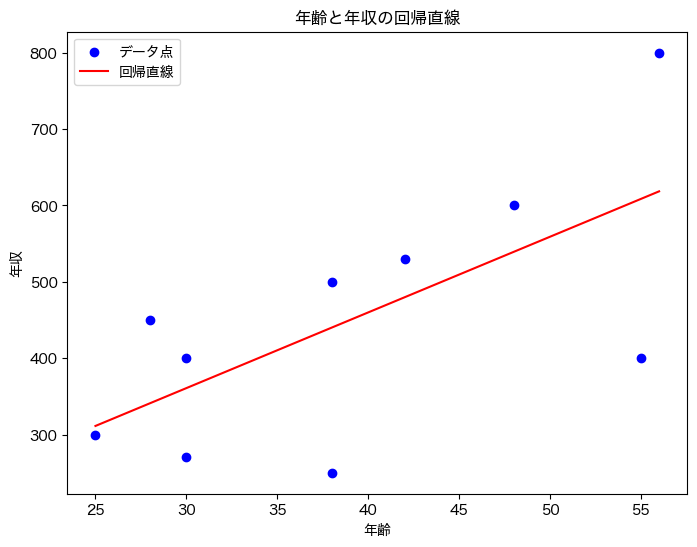

In [ ]:
# 回帰直線の計算
x_vals = sorted(df["age"])
y_vals = [a + b * x for x in x_vals]

# グラフ描画
plt.figure(figsize=(8, 6))
plt.scatter(df["age"], df["income"], color='blue', label='データ点')
plt.plot(x_vals, y_vals, color='red', label='回帰直線')
plt.xlabel("年齢")
plt.ylabel("年収")
plt.title("年齢と年収の回帰直線")
plt.legend()
plt.grid(True)
plt.show()

## 演習： 耕地面積と販売金額

次のデータは，北海道のある地域から無作為に抽出した20戸の農家の農産物の2005年度の販売金額と総経営耕地面積のデータである．

In [18]:
farm_sales_data = [
    {"農家番号": 1, "農産物の販売金額": 400, "総経営耕地面積": 60},
    {"農家番号": 2, "農産物の販売金額": 15, "総経営耕地面積": 30},
    {"農家番号": 3, "農産物の販売金額": 480, "総経営耕地面積": 365},
    {"農家番号": 4, "農産物の販売金額": 993, "総経営耕地面積": 190},
    {"農家番号": 5, "農産物の販売金額": 600, "総経営耕地面積": 136},
    {"農家番号": 6, "農産物の販売金額": 150, "総経営耕地面積": 15},
    {"農家番号": 7, "農産物の販売金額": 115, "総経営耕地面積": 37},
    {"農家番号": 8, "農産物の販売金額": 50, "総経営耕地面積": 100},
    {"農家番号": 9, "農産物の販売金額": 0, "総経営耕地面積": 170},
    {"農家番号": 10, "農産物の販売金額": 130, "総経営耕地面積": 70},
    {"農家番号": 11, "農産物の販売金額": 3000, "総経営耕地面積": 783},
    {"農家番号": 12, "農産物の販売金額": 500, "総経営耕地面積": 560},
    {"農家番号": 13, "農産物の販売金額": 200, "総経営耕地面積": 50},
    {"農家番号": 14, "農産物の販売金額": 55, "総経営耕地面積": 35},
    {"農家番号": 15, "農産物の販売金額": 2200, "総経営耕地面積": 595},
    {"農家番号": 16, "農産物の販売金額": 1, "総経営耕地面積": 200},
    {"農家番号": 17, "農産物の販売金額": 900, "総経営耕地面積": 300},
    {"農家番号": 18, "農産物の販売金額": 1000, "総経営耕地面積": 356},
    {"農家番号": 19, "農産物の販売金額": 450, "総経営耕地面積": 155},
    {"農家番号": 20, "農産物の販売金額": 400, "総経営耕地面積": 250}
]

### データフレームにする

In [20]:
df= pd.DataFrame(farm_sales_data)
df.head()

,農家番号,農産物の販売金額,総経営耕地面積
0,1,400,60
1,2,15,30
2,3,480,365
3,4,993,190
4,5,600,136


### (1) 総経営耕地面積を説明変数，販売金額を目的変数として，回帰係数と定数の値を求めよ．

注意：変数を逆にしないように注意すること

In [25]:
# 平均値（X̄, Ȳ）
X_bar = df["総経営耕地面積"].mean()
Y_bar = df["農産物の販売金額"].mean()

# 分子：Sxy = Σ(Xi - X̄)(Yi - Ȳ)
Sxy = ((df["総経営耕地面積"] - X_bar) * (df["農産物の販売金額"] - Y_bar)).sum()

# 分母：Sxx = Σ(Xi - X̄)^2
Sxx = ((df["総経営耕地面積"] - X_bar) ** 2).sum()

# 回帰係数 b と 切片 a
b = Sxy / Sxx
a = Y_bar - b * X_bar

# 出力
print(f"X̄ = {X_bar:.2f}, Ȳ = {Y_bar:.2f}")
print(f"Sxy = {Sxy:.2f}, Sxx = {Sxx:.2f}")
print(f"回帰係数 b = {b:.2f}")
print(f"切片 a = {a:.2f}")

X̄ = 222.85, Ȳ = 581.95
Sxy = 2642648.85, Sxx = 872172.55
回帰係数 b = 3.03
切片 a = -93.28


### (2) (1)の結果からわかる回帰式を用いて，耕地面積200に対する販売金額の予測値，耕地面積700に対する販売金額の予測値を求めよ

In [27]:
# 回帰式による予測関数
def predict(x):
    return a + b * x

print(f"耕地面積200に対する販売金額の予測値: {predict(200):.2f}")
print(f"耕地面積700に対する販売金額の予測値: {predict(700):.2f}")

耕地面積200に対する販売金額の予測値: 512.72
耕地面積700に対する販売金額の予測値: 2027.70


### (3) データと回帰直線をグラフで図示せよ

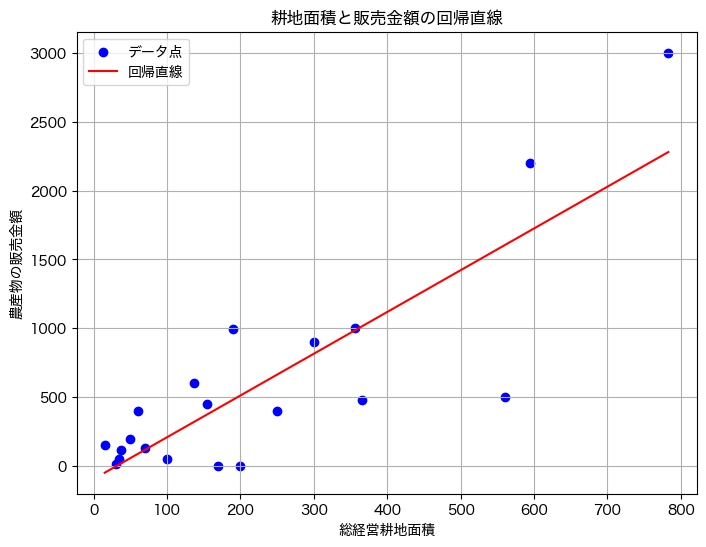

In [26]:
# 回帰直線の計算
x_vals = sorted(df["総経営耕地面積"])
y_vals = [a + b * x for x in x_vals]

# グラフ描画
plt.figure(figsize=(8, 6))
plt.scatter(df["総経営耕地面積"], df["農産物の販売金額"], color='blue', label='データ点')
plt.plot(x_vals, y_vals, color='red', label='回帰直線')
plt.xlabel("総経営耕地面積")
plt.ylabel("農産物の販売金額")
plt.title("耕地面積と販売金額の回帰直線")
plt.legend()
plt.grid(True)
plt.show()